# EDA — Diabetes 30-Day Readmission

Purpose: verify the handout's claims against our actual data and gather the evidence needed
to decide the cleaning rules before writing `src/data/clean.py`.

Questions this notebook answers:
1. How much is actually missing per column (after treating `?` as NaN)?
2. What is the real class balance (3-class and our binary `<30` target)?
3. How many patients have multiple encounters (row-split leakage risk)?
4. How many encounters can't be readmitted (death/hospice discharge) and should be excluded?
5. Which columns are constant or near-constant (candidates to drop)?
6. How high-cardinality are the diagnosis codes?
7. Demographic distributions (needed later for the fairness audit).
8. Do the expected signals (prior inpatient visits, A1C) show up?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 160)

# Trap #1: missing values are coded as '?'
df = pd.read_csv('../data_folder/diabetic_data.csv', na_values='?')
print(f'shape: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'unique encounters: {df.encounter_id.nunique():,}')
print(f'unique patients:   {df.patient_nbr.nunique():,}')

shape: 101,766 rows x 50 cols
unique encounters: 101,766
unique patients:   71,518


C:\Users\Mouli\AppData\Local\Temp\ipykernel_21976\2931457988.py:10: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data_folder/diabetic_data.csv', na_values='?')


## 1. Missingness per column

In [2]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
print(pd.DataFrame({'n_missing': miss, 'pct_missing': miss_pct}).to_string())

# 'None' in A1Cresult / max_glu_serum is NOT missing — it means 'test not performed'
print('\nA1Cresult values:');     print(df.A1Cresult.value_counts(dropna=False).to_string())
print('\nmax_glu_serum values:'); print(df.max_glu_serum.value_counts(dropna=False).to_string())

                   n_missing  pct_missing
weight                 98569        96.86
max_glu_serum          96420        94.75
A1Cresult              84748        83.28
medical_specialty      49949        49.08
payer_code             40256        39.56
race                    2273         2.23
diag_3                  1423         1.40
diag_2                   358         0.35
diag_1                    21         0.02

A1Cresult values:
A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812

max_glu_serum values:
max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264


## 2. Target: class balance

readmitted
NO     54864
>30    35545
<30    11357
readmitted
NO     53.91
>30    34.93
<30    11.16

binary target (<30 vs rest): 0.1116 positive rate (11,357 of 101,766)


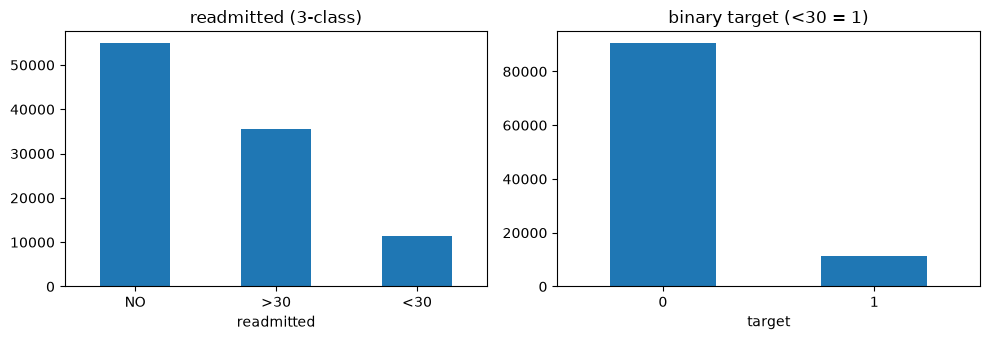

In [3]:
print(df.readmitted.value_counts().to_string())
print((df.readmitted.value_counts(normalize=True) * 100).round(2).to_string())

df['target'] = (df.readmitted == '<30').astype(int)
print(f"\nbinary target (<30 vs rest): {df.target.mean():.4f} positive rate "
      f"({df.target.sum():,} of {len(df):,})")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
df.readmitted.value_counts().plot.bar(ax=ax[0], title='readmitted (3-class)', rot=0)
df.target.value_counts().plot.bar(ax=ax[1], title='binary target (<30 = 1)', rot=0)
plt.tight_layout(); plt.show()

## 3. Patient duplication — why we must split by patient ID

In [4]:
enc_per_patient = df.groupby('patient_nbr').size()
multi = enc_per_patient[enc_per_patient > 1]
print(f'patients total:                 {len(enc_per_patient):,}')
print(f'patients with >1 encounter:     {len(multi):,} ({len(multi)/len(enc_per_patient)*100:.1f}%)')
print(f'rows belonging to those:        {multi.sum():,} ({multi.sum()/len(df)*100:.1f}% of all rows)')
print(f'max encounters for one patient: {enc_per_patient.max()}')
print('\nencounters-per-patient distribution:')
print(enc_per_patient.value_counts().sort_index().head(10).to_string())

patients total:                 71,518
patients with >1 encounter:     16,773 (23.5%)
rows belonging to those:        47,021 (46.2% of all rows)
max encounters for one patient: 40

encounters-per-patient distribution:
1     54745
2     10434
3      3328
4      1421
5       717
6       346
7       207
8       111
9        70
10       42


## 4. Encounters that cannot be readmitted

Discharge dispositions meaning the patient died or went to hospice
(ids 11, 13, 14, 19, 20, 21 per IDS_mapping.csv) — a readmission is impossible,
so keeping them teaches the model nonsense.

In [5]:
# IDS_mapping.csv holds three stacked tables separated by blank lines — parse them
import csv, io
sections, current = {}, None
with open('../data_folder/IDS_mapping.csv', newline='') as f:
    for row in csv.reader(f):
        if not row or not row[0].strip():
            current = None
        elif current is None:
            current = row[0]
            sections[current] = {}
        else:
            sections[current][int(row[0])] = row[1]
disp_map = sections['discharge_disposition_id']

DEATH_HOSPICE_IDS = [11, 13, 14, 19, 20, 21]
for i in DEATH_HOSPICE_IDS:
    print(f'{i:>3}  {disp_map[i]}')

mask = df.discharge_disposition_id.isin(DEATH_HOSPICE_IDS)
print(f'\nrows affected: {mask.sum():,} ({mask.mean()*100:.2f}%)')
print(f'their <30 readmission rate: {df.loc[mask, "target"].mean():.4f} '
      f'(vs {df.loc[~mask, "target"].mean():.4f} for the rest)')

 11  Expired
 13  Hospice / home
 14  Hospice / medical facility
 19  Expired at home. Medicaid only, hospice.
 20  Expired in a medical facility. Medicaid only, hospice.
 21  Expired, place unknown. Medicaid only, hospice.

rows affected: 2,423 (2.38%)
their <30 readmission rate: 0.0177 (vs 0.1139 for the rest)


## 5. Constant and near-constant columns

In [6]:
nunique = df.nunique()
print('columns with a single value:')
print(nunique[nunique == 1].to_string())

med_cols = df.columns[df.columns.get_loc('metformin'):df.columns.get_loc('metformin-pioglitazone')+1]
dominance = pd.Series({c: df[c].value_counts(normalize=True).iloc[0] for c in med_cols})
print('\nmedication columns where one value covers >99% of rows:')
print((dominance[dominance > 0.99].sort_values(ascending=False) * 100).round(2).to_string())

columns with a single value:
examide        1
citoglipton    1

medication columns where one value covers >99% of rows:
examide                     100.00
citoglipton                 100.00
acetohexamide               100.00
glimepiride-pioglitazone    100.00
metformin-pioglitazone      100.00
metformin-rosiglitazone     100.00
troglitazone                100.00
glipizide-metformin          99.99
tolbutamide                  99.98
miglitol                     99.96
tolazamide                   99.96
chlorpropamide               99.92
acarbose                     99.70
nateglinide                  99.31
glyburide-metformin          99.31


## 6. Diagnosis code cardinality (ICD-9)

In [7]:
for c in ['diag_1', 'diag_2', 'diag_3']:
    print(f'{c}: {df[c].nunique():,} unique codes, {df[c].isna().sum():,} missing')
print('\ntop 10 primary diagnoses:')
print(df.diag_1.value_counts().head(10).to_string())

diag_1: 716 unique codes, 21 missing
diag_2: 748 unique codes, 358 missing
diag_3: 789 unique codes, 1,423 missing

top 10 primary diagnoses:
diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028


## 7. Demographics & readmission rate by group (fairness-audit preview)


--- race ---
                     n  readmit_rate
race                                
AfricanAmerican  19210        0.1122
Asian              641        0.1014
Caucasian        76099        0.1129
Hispanic          2037        0.1041
Other             1506        0.0963
NaN               2273        0.0827



--- gender ---
                     n  readmit_rate
gender                              
Female           54708        0.1125
Male             47055        0.1106
Unknown/Invalid      3        0.0000

--- age ---
              n  readmit_rate
age                          
[0-10)      161        0.0186
[10-20)     691        0.0579
[20-30)    1657        0.1424
[30-40)    3775        0.1123
[40-50)    9685        0.1060
[50-60)   17256        0.0967
[60-70)   22483        0.1113
[70-80)   26068        0.1177
[80-90)   17197        0.1208
[90-100)   2793        0.1110


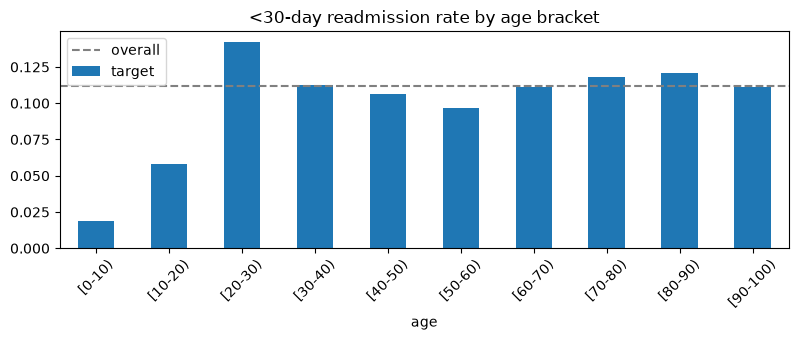

In [8]:
for col in ['race', 'gender', 'age']:
    g = df.groupby(col, dropna=False, observed=True).agg(
        n=('target', 'size'), readmit_rate=('target', 'mean')).round(4)
    print(f'\n--- {col} ---'); print(g.to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
df.groupby('age', observed=True).target.mean().plot.bar(ax=ax, rot=45,
    title='<30-day readmission rate by age bracket')
ax.axhline(df.target.mean(), ls='--', c='gray', label='overall')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Expected signals: prior visits, A1C, medication change

readmission rate by number of prior INPATIENT visits:
                      n    rate
number_inpatient               
0                 67630  0.0844
1                 19521  0.1292
2                  7566  0.1743
3                  3411  0.2029
4                  1622  0.2361
5                  2016  0.3641

readmission rate by number of prior EMERGENCY visits:
                      n    rate
number_emergency               
0                 90383  0.1047
1                  7677  0.1435
2                  2042  0.1827
3                  1664  0.2494

readmission rate by A1Cresult (None = not measured):
               n    rate
A1Cresult               
>7          3812  0.1005
>8          8216  0.0987
Norm        4990  0.0966
NaN        84748  0.1142

readmission rate by medication change / diabetesMed:


                        n    rate
change diabetesMed               
Ch     Yes          47011  0.1182
No     No           23403  0.0960
       Yes          31352  0.1133


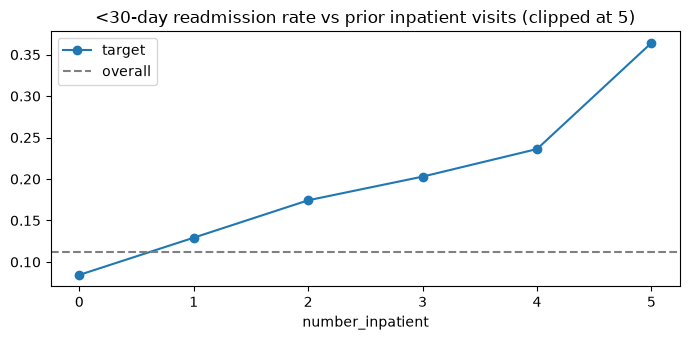

In [9]:
print('readmission rate by number of prior INPATIENT visits:')
binned = df.number_inpatient.clip(upper=5)
print(df.groupby(binned).agg(n=('target', 'size'), rate=('target', 'mean')).round(4).to_string())

print('\nreadmission rate by number of prior EMERGENCY visits:')
print(df.groupby(df.number_emergency.clip(upper=3)).agg(
    n=('target', 'size'), rate=('target', 'mean')).round(4).to_string())

print('\nreadmission rate by A1Cresult (None = not measured):')
print(df.groupby('A1Cresult', dropna=False).agg(
    n=('target', 'size'), rate=('target', 'mean')).round(4).to_string())

print('\nreadmission rate by medication change / diabetesMed:')
print(df.groupby(['change', 'diabetesMed']).agg(
    n=('target', 'size'), rate=('target', 'mean')).round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 3.5))
df.groupby(binned).target.mean().plot(marker='o', ax=ax,
    title='<30-day readmission rate vs prior inpatient visits (clipped at 5)')
ax.axhline(df.target.mean(), ls='--', c='gray', label='overall')
ax.set_xlabel('number_inpatient'); ax.legend(); plt.tight_layout(); plt.show()

In [10]:
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
print(df[num_cols].describe().T.round(2).to_string())
print('\npoint-biserial correlation with binary target:')
print(df[num_cols].corrwith(df.target).sort_values(ascending=False).round(4).to_string())

                       count   mean    std  min   25%   50%   75%    max
time_in_hospital    101766.0   4.40   2.99  1.0   2.0   4.0   6.0   14.0
num_lab_procedures  101766.0  43.10  19.67  1.0  31.0  44.0  57.0  132.0
num_procedures      101766.0   1.34   1.71  0.0   0.0   1.0   2.0    6.0
num_medications     101766.0  16.02   8.13  1.0  10.0  15.0  20.0   81.0
number_outpatient   101766.0   0.37   1.27  0.0   0.0   0.0   0.0   42.0
number_emergency    101766.0   0.20   0.93  0.0   0.0   0.0   0.0   76.0
number_inpatient    101766.0   0.64   1.26  0.0   0.0   0.0   1.0   21.0
number_diagnoses    101766.0   7.42   1.93  1.0   6.0   8.0   9.0   16.0

point-biserial correlation with binary target:
number_inpatient      0.1651
number_emergency      0.0607
number_diagnoses      0.0495
time_in_hospital      0.0442
num_medications       0.0384
num_lab_procedures    0.0204
number_outpatient     0.0189
num_procedures       -0.0122


## Findings → cleaning decisions (agreed 2026-06-12)

These rules will be implemented in `src/data/clean.py`; each logs row counts before/after.

### Cleaning rules
1. **Load with `na_values='?'`** — but protect `A1Cresult` / `max_glu_serum` from pandas'
   default `"None"`→NaN conversion. "None" there means **test not performed**, its own
   category (`NotMeasured`) — patients with no A1C test readmit *more* (11.4%) than any
   measured group (9.7–10.1%). Never impute a normal value.
2. **Drop columns**: `weight` (96.9% missing), `examide`, `citoglipton` (single-valued).
3. **Drop rows**: `gender == "Unknown/Invalid"` (3 rows); discharge dispositions
   **11, 13, 14, 19, 20, 21** (expired/hospice — readmission impossible; 2,423 rows, 2.4%).
4. **Missing → explicit "Missing" category**: `medical_specialty` (49.1%), `payer_code`
   (39.6%), `race` (2.2%). Missingness is informative; do not impute or drop.
5. **Target**: `target = (readmitted == "<30")` → ~11.16% positive.
6. **Split by `patient_nbr`** — 23.5% of patients have >1 encounter = 46.2% of all rows;
   a random row split would leak heavily.

### Column inventory (after cleaning)

| Role | Columns |
|---|---|
| Identifiers (not features) | `encounter_id`; `patient_nbr` (split groups only) |
| Numerical (8) | `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_outpatient`, `number_emergency`, `number_inpatient`, `number_diagnoses` |
| Categorical — demographics | `race`, `gender`, `age` (ordinal brackets → encode as ordered) |
| Categorical — admission codes | `admission_type_id`, `discharge_disposition_id`, `admission_source_id` (integers but categorical — map via IDS_mapping, collapse NULL/Not Available/Not Mapped) |
| Categorical — context | `medical_specialty`, `payer_code` |
| Categorical — diagnoses | `diag_1`, `diag_2`, `diag_3` (716–789 unique ICD-9 codes → clinical buckets in Stage 2) |
| Categorical — labs | `max_glu_serum`, `A1Cresult` (keep `NotMeasured`) |
| Categorical — medications (21 kept) | `metformin` … `metformin-pioglitazone` minus the two constants; plus `change`, `diabetesMed` |
| Target | `readmitted` → binary `target` |

### Why we are NOT dropping low-correlation columns at this stage
Point-biserial correlation only measures **linear, univariate** association on numeric
columns. Tree models (XGBoost/LightGBM) exploit non-linearities and interactions that
univariate correlation cannot see, and the near-constant medication columns feed the
Stage-2 engineered features (medication-change count, active-meds count). With 100k rows
and ~50 columns there is no compute pressure. Strategy: keep everything non-constant,
let the model + SHAP importance rank features, and prune *afterwards* with evidence —
pruning before modeling is premature and we could not justify it in the write-up.

### Signal preview (sanity check for Stage 3)
- `number_inpatient` is the strongest single predictor: 8.4% → 36.4% readmission rate
  from 0 to 5+ prior inpatient visits (corr 0.165).
- `number_emergency` second (corr 0.061); everything else ≤ 0.05 univariately.
- Demographic readmission rates are fairly even (race 9.6–11.3%, gender ~11%) —
  baseline context for the Stage-6 fairness audit; missing-race group is lower (8.3%).